In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
from adjustText import adjust_text
from upsetplot import UpSet, from_contents
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="upsetplot"
)

In [2]:
# trait
trait_df = pd.read_csv('../data/TM_FACS/trait_name_map.tsv', header=0, index_col=None, sep='\t')
trait_df = trait_df[(trait_df['include'] == 'Yes') & (trait_df['representative'] == 'Yes')]
trait_order = trait_df['trait'].values
trait_shortname = trait_df['trait_short_name'].values

# cell type
ct_df = pd.read_csv('../data/TM_FACS/celltype_name_map.tsv', header=0, index_col=None, sep='\t')
ct_df = ct_df[ct_df['representative'] == 'Yes']
ct_order = ct_df['cell_type'].values
ct_shortname = ct_df['name'].values

In [3]:
trait_df['category'].unique()

array(['Blood trait', 'Immune', 'Metabolic', 'Neurological',
       'Cardiovascular', 'Respiratory', 'Others'], dtype=object)

In [4]:
ct_df['category'].unique()

array(['Blood', 'Immune', 'Liver', 'Pancreas', 'Brain', 'Heart', 'Lung',
       'Muscle', 'Epithelial', 'Skin', 'Mammary gland', 'Cartilage',
       'Stromal', 'Large intestine'], dtype=object)

## check heatmap

In [5]:
def plot_hm(icepop_df, outfile=None):
    pivot_df = icepop_df.pivot(index='trait', columns='cell_type', values='z')
    pivot_df = pivot_df.loc[trait_order, ct_order]
    
    bin_pivot_df = icepop_df.pivot(index='trait', columns='cell_type', values='discovery')
    bin_pivot_df = bin_pivot_df.loc[trait_order, ct_order]
    
    mix_pivot_df = icepop_df.pivot(index='trait', columns='cell_type', values='sig_pct')
    mix_pivot_df = (mix_pivot_df <= 0.8) & (mix_pivot_df >= 0.2)
    mix_pivot_df = mix_pivot_df.loc[trait_order, ct_order]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    hm = sns.heatmap(
        pivot_df,
        cmap='Reds', linewidths=0.01, linecolor='lightgrey',
        ax=ax, vmin=0, vmax=5, cbar_kws={"shrink": 0.7}
    )
    
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            if bin_pivot_df.iloc[i, j]:
                ax.add_patch(
                    Rectangle(
                        (j, i),           # (x, y)
                        1, 1,              # width, height
                        fill=False,
                        edgecolor='black', # or 'white'
                        linewidth=1.8
                    )
                )
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            if mix_pivot_df.iloc[i, j]:
                ax.text(j + 0.5, i + 0.6, 'X', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
                
    ax.tick_params(left=False, bottom=False)
    
    # make legend (colorbar) smaller
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label('Association z-score', fontsize=15)
    cbar.ax.set_position([0.76, 0.4, 0.1, 0.3])
    
    # Thicken the outer border (spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)   # thicker border
    
    ax.set_xticklabels(ct_shortname, rotation=45, ha='right', fontsize=11.5)
    ax.set_yticklabels(trait_shortname, fontsize=11.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    else:
        plt.show()

In [6]:
dfs = []
for size in [30, 50, 75]:
    indir = f'../results/TM_icepop_mc-{size}'
    for file in Path(indir).rglob('celltype__trait-*.csv'):
        df = pd.read_csv(file, header=0, index_col=None)
        df['trait'] = Path(file).stem.split('trait-')[1]
        df['mc_size'] = size
        dfs.append(df)
icepop_df = pd.concat(dfs, ignore_index=True)
icepop_df['discovery'] = icepop_df['q'] <= 0.1
icepop_df['mixture'] = icepop_df['sig_pct'] <= 0.2

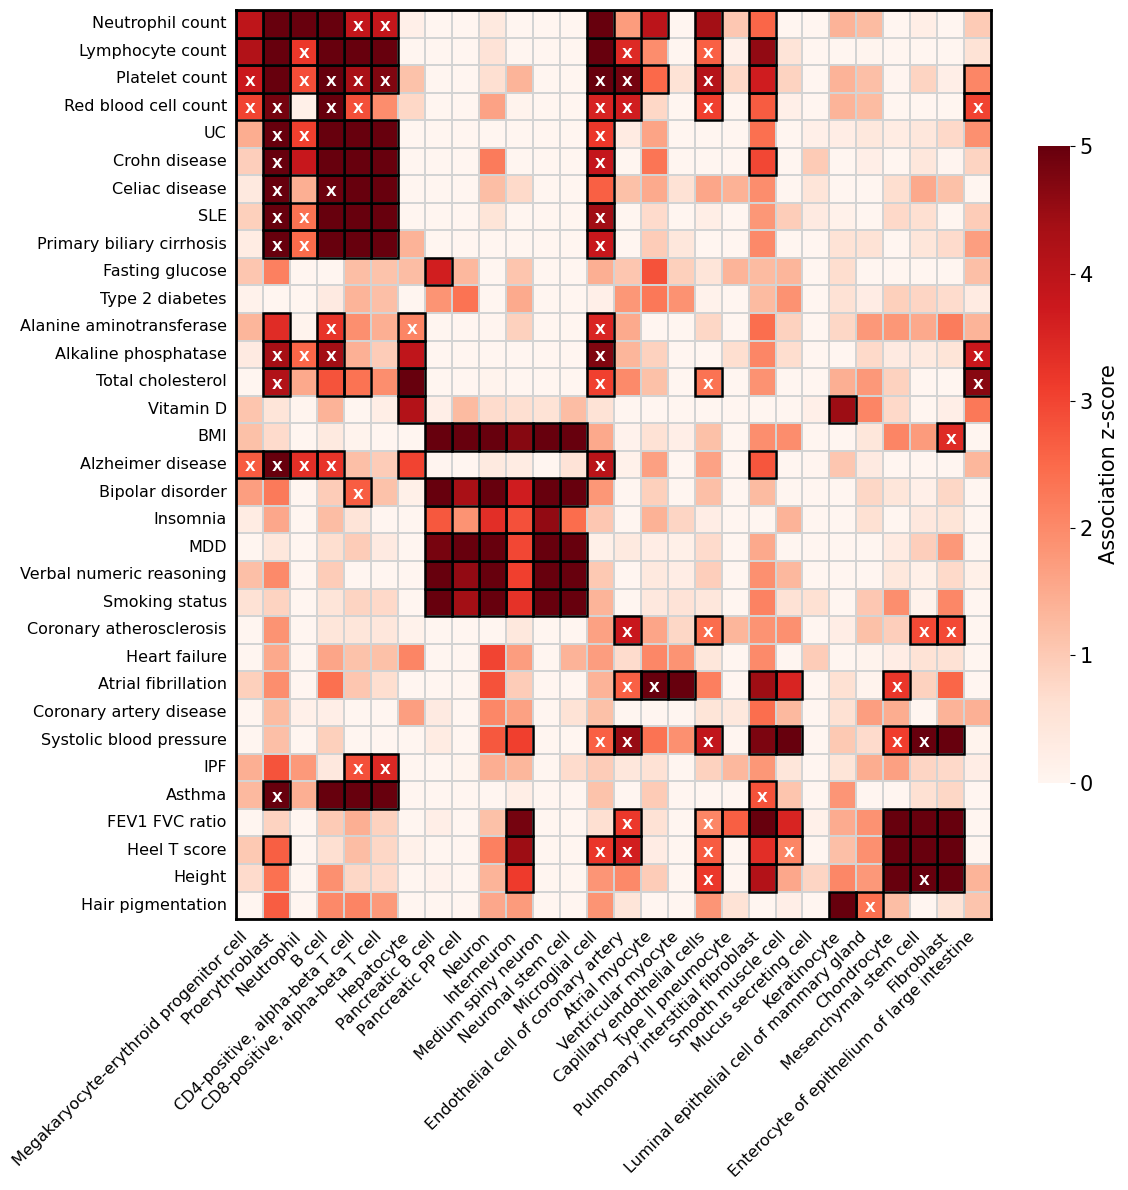

In [7]:
# mc size 30
plot_hm(icepop_df[icepop_df['mc_size'] == 30], outfile='../paper/supp/TM_heatmap_mc30.pdf')

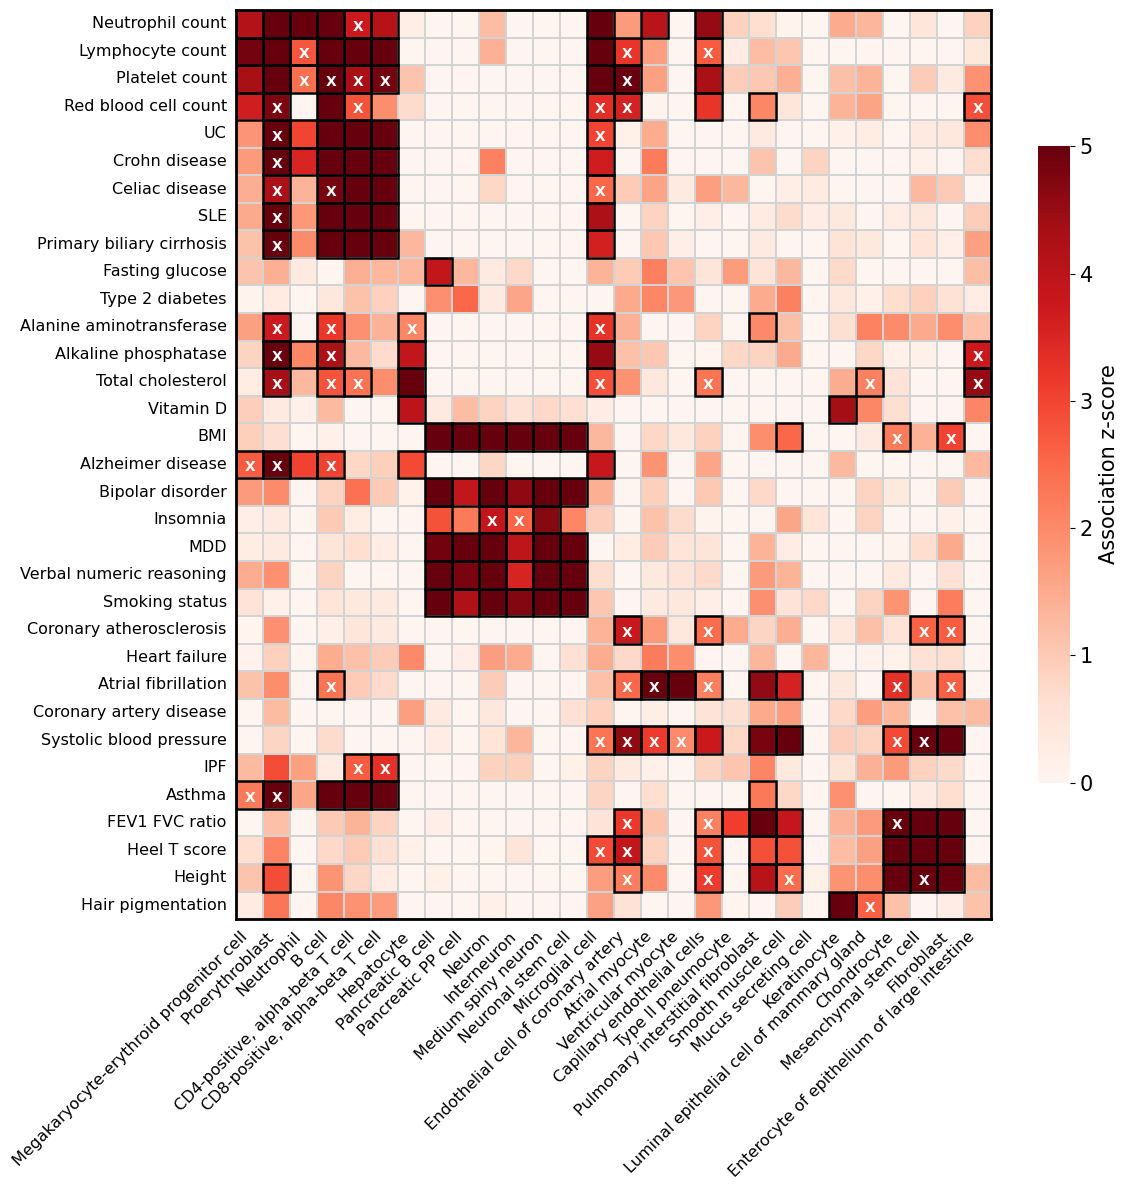

In [8]:
# mc size 50
plot_hm(icepop_df[icepop_df['mc_size'] == 50], outfile='../paper/supp/TM_heatmap_mc50.pdf')

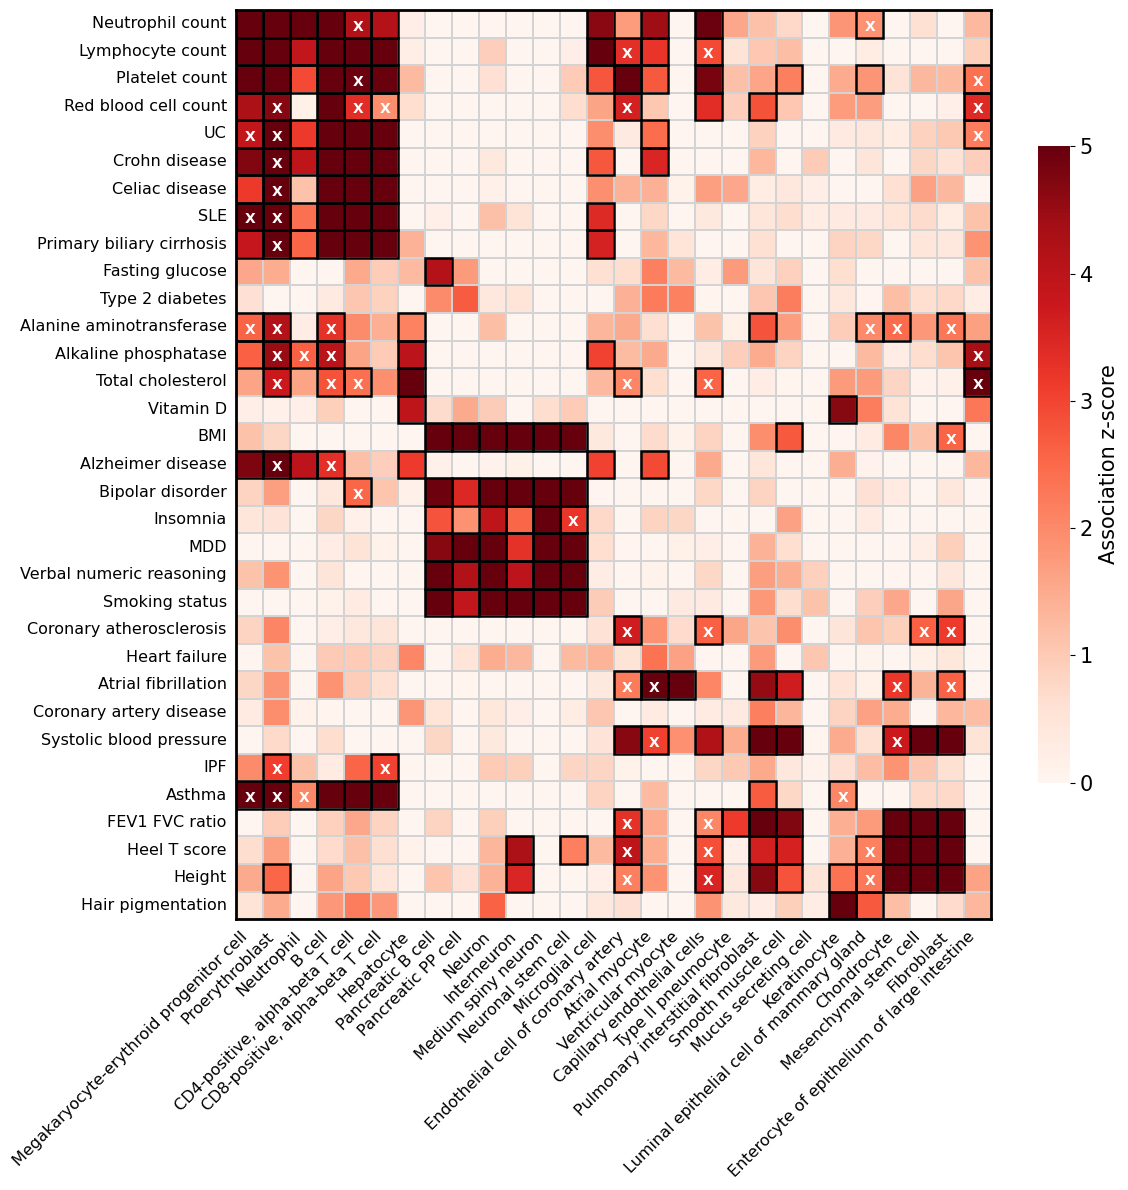

In [9]:
# mc size 75
plot_hm(icepop_df[icepop_df['mc_size'] == 75], outfile='../paper/supp/TM_heatmap_mc75.pdf')

## Compare differential associations

In [10]:
comb_df = []
for size in [30, 50, 75]:
    df = (
        icepop_df[icepop_df["mc_size"] == size]
        .sort_values(by=['cell_type', 'trait'])
        .reset_index(drop=True)
        .rename(columns={"discovery": f"mc{size}_discovery", "mixture": f"mc{size}_mixture"})
    )
    if size == 30:
        comb_df.append(df.loc[:, ['cell_type', 'trait', f"mc{size}_discovery", f"mc{size}_mixture"]])
    else:
        comb_df.append(df.loc[:, [f"mc{size}_discovery", f"mc{size}_mixture"]])
comb_df = pd.concat(comb_df, axis=1)

# rename cell type and trait
# import all traits and cell types
trait_df = pd.read_csv('../data/TM_FACS/trait_name_map.tsv', header=0, index_col=None, sep='\t')
trait_df = trait_df[trait_df['include'] == 'Yes']
ct_df = pd.read_csv('../data/TM_FACS/celltype_name_map.tsv', header=0, index_col=None, sep='\t')
name_map = trait_df.set_index('trait')
ct_name_map = ct_df.set_index('cell_type')
comb_df = comb_df[comb_df['trait'].isin(trait_df['trait'])].copy()
comb_df['trait_full_name'] = list(name_map.loc[comb_df['trait'], 'trait_full_name'])
comb_df['celltype_name'] = list(ct_name_map.loc[comb_df['cell_type'], 'name'])

<Figure size 600x400 with 0 Axes>

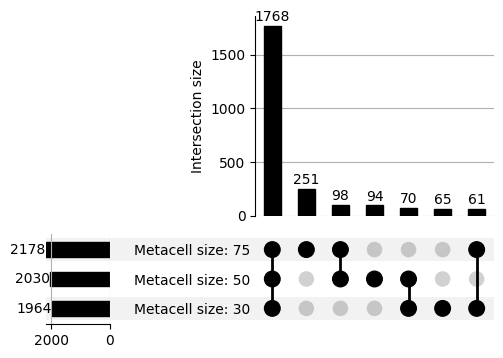

In [11]:
mc30_idx = set(comb_df[comb_df['mc30_discovery']].index.values)
mc50_idx = set(comb_df[comb_df['mc50_discovery']].index.values)
mc75_idx = set(comb_df[comb_df['mc75_discovery']].index.values)

sets = {
    "Metacell size: 30": mc30_idx,
    "Metacell size: 50": mc50_idx,
    "Metacell size: 75": mc75_idx,
}

data = from_contents(sets)
plt.figure(figsize=(6, 4))
UpSet(
    data,
    sort_categories_by=None,
    show_counts=True,
    sort_by='cardinality'
).plot()
plt.savefig('../paper/supp/tm_upset_mc_discovery_compare.pdf')

<Figure size 600x400 with 0 Axes>

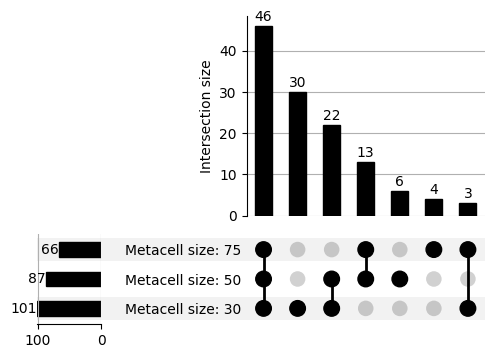

In [12]:
shared_df = comb_df[
    comb_df['mc30_discovery'] &
    comb_df['mc50_discovery'] &
    comb_df['mc75_discovery']
]

mc30_idx = set(shared_df[shared_df['mc30_mixture']].index.values)
mc50_idx = set(shared_df[shared_df['mc50_mixture']].index.values)
mc75_idx = set(shared_df[shared_df['mc75_mixture']].index.values)

sets = {
    "Metacell size: 30": mc30_idx,
    "Metacell size: 50": mc50_idx,
    "Metacell size: 75": mc75_idx,
}

data = from_contents(sets)
plt.figure(figsize=(6, 4))
UpSet(
    data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
).plot()
plt.savefig('../paper/supp/tm_upset_mc_mix_compare.pdf')

## check metacell size stats

In [13]:
dfs = []
for mcsize in [30, 50, 75]:
    df = pd.read_csv(f'../results/TM_FACS_mc-{mcsize}/mc_stats.csv', header=0, index_col=0)
    df['ave_mc'] = mcsize
    dfs.append(df)
stats_df = pd.concat(dfs, ignore_index=True)

/tmp/ipykernel_777393/4203785252.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


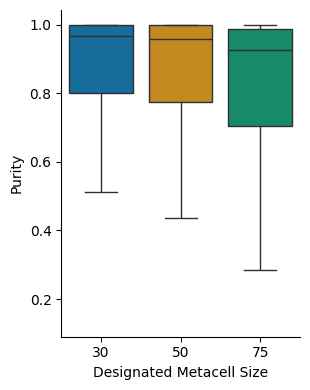

In [14]:
# Set publication-style theme
plt.figure(figsize=(3.2, 4))

ax = sns.boxplot(
    data=stats_df,
    x="ave_mc",
    y="purity",
    fliersize=0,
    palette="colorblind",
)

# Labels and title
ax.set_xlabel("Designated Metacell Size")
ax.set_ylabel("Purity")
# ax.set_title("Purity by Designated Metacell Size", pad=8)

# Clean spines
sns.despine()

# Improve layout
plt.tight_layout()

# Save as high-quality PDF (vector format)
plt.savefig("../paper/supp/purity_by_mcsize.pdf", 
            format="pdf", 
            bbox_inches="tight")

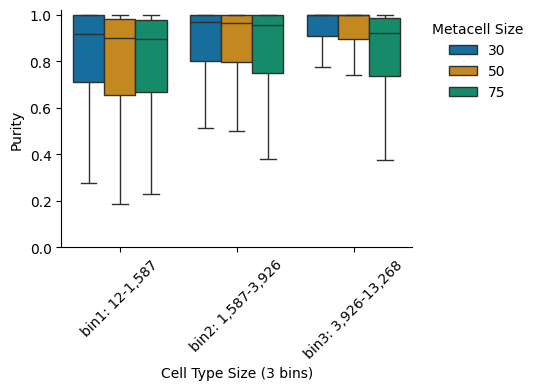

In [15]:
# ----------------------------
# Create quantile bins
# ----------------------------
n_bins = 3
bins = pd.qcut(stats_df["cell_type_size"], q=n_bins)
edges = bins.cat.categories

labels = []
for i, interval in enumerate(edges):
    left = int(np.floor(interval.left))
    right = int(np.ceil(interval.right))
    labels.append(f"bin{i+1}: {left:,}-{right:,}")

stats_df["ct_size_bin"] = pd.qcut(
    stats_df["cell_type_size"],
    q=n_bins,
    labels=labels
)

# ----------------------------
# Publication styling
# ----------------------------
plt.figure(figsize=(5.5, 4))

ax = sns.boxplot(
    data=stats_df,
    x="ct_size_bin",
    y="purity",
    hue="ave_mc",
    palette="colorblind",
    fliersize=0,
    linewidth=1,
    dodge=True
)

# Axis formatting
ax.set_xlabel(f"Cell Type Size ({n_bins} bins)")
ax.set_ylabel("Purity")
ax.set_ylim(0, 1.02)

plt.xticks(rotation=45, ha="center")

# Clean spines
sns.despine()

# Legend formatting
plt.legend(
    title="Metacell Size",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save high-quality vector PDF
plt.savefig(
    "../paper/supp/purity_by_ct_mcsize.pdf",
    format="pdf",
    bbox_inches="tight"
)